# Uniaxial Strain and the Piezoresistive Response of Silicon

This notebook builds the uniaxial ($\Gamma_{12}$) channel of the piezoresistivity pipeline, replacing empirical piezoresistive coefficients with a first-principles description of how silicon's conduction electrons respond to strain.

The physical picture rests on a single idea: the conduction band of silicon is not a single bowl but six equivalent valleys along the cubic axes, each an anisotropic ellipsoid. As long as the crystal keeps its cubic symmetry these valleys are indistinguishable, and the material conducts the same in every direction. The moment strain singles out one axis, that balance is broken — the valleys shift in energy, electrons redistribute among them, and the conductivity becomes directional. That directional response is precisely what a piezoresistance measurement sees.

**Structure.** Part 1 states the theory. Part 2 validates the effective-mass extraction against literature — the prerequisite for everything downstream. Part 3 runs the strain sweep and extracts $\Xi_u$. Part 4 assembles the conductivity tensor. Part 5 converts strain to stress and benchmarks against Smith (1954). Part 6 documents the linear-response validity range. Part 7 exposes the tensor to the FEM layer.


---
# Part 1 — Theory: valley repopulation

*Companion note to the effective-mass foundation. Where the mass work ends — six fixed ellipsoids with their longitudinal and transverse masses — this picks up, and asks how strain moves carriers between those ellipsoids to produce a strain-dependent conductivity $\sigma(\varepsilon)$.*

## The one thing to hold onto

The masses never change; the populations do. This is the load-bearing fact of the entire channel, and everything else is its consequence.

Strain does not reshape any valley. It shifts each valley's energy, and by doing so redistributes carriers among the six fixed ellipsoids. Because those ellipsoids point along different axes and present a heavy mass along one direction and a light mass across the others, moving carriers from one group of valleys to another changes how the crystal conducts overall — even though not a single mass has moved. The valley shapes $m_l, m_t$ are frozen; only their occupations $n_i(\varepsilon)$ respond to strain. The shapes stay fixed because the shift $\Xi_u(\hat m_i\cdot\varepsilon\cdot\hat m_i)$ is independent of $k$ and so leaves the curvature untouched, while the occupations move because they are Boltzmann weights evaluated on the shifted energies.

It is worth contrasting this with the cyclotron picture. There, tilting the magnetic field changed the *apparent* mass by geometrically projecting a fixed tensor onto a new direction. Here, strain changes the *occupancy* of valleys whose tensors stay exactly as they were. Both leave the masses untouched; they simply do different things to the same set of cigars — one projects, the other repopulates.


## How strain moves the valley energies

Under strain each valley shifts in energy by the Herring–Vogt form,

$$\Delta E_i(\varepsilon) = a\,\mathrm{Tr}(\varepsilon) \;+\; \Xi_u\,\big(\hat m_i^{\mathsf T}\, \varepsilon\, \hat m_i\big),$$

a sum of two contributions of very different character. The first, $a\,\mathrm{Tr}(\varepsilon)$, is hydrostatic — it raises or lowers every valley by the same amount, belongs to the $\Gamma_1$ channel, and cannot by itself distinguish one valley from another. The second is the only term that depends on how each valley's own axis is oriented relative to the strain, and therefore shifts the six valleys by *different* amounts. This is the $\Gamma_{12}$ piece, and it is the sole origin of the splitting.

### Reading the quadratic form

$\hat m_i$ is **not a mass** — it is the *unit vector* along valley $i$'s axis. (The notation is unfortunate; Herring & Vogt originally wrote $\hat a_i$.) The same unit vector defines the direction along which the mass is $m_l$:

$$M_i^{-1} = \frac{1}{m_t}\big(I - \hat m_i \hat m_i^{\mathsf T}\big) + \frac{1}{m_l}\,\hat m_i \hat m_i^{\mathsf T}$$

The sandwich $\hat m^{\mathsf T}\varepsilon\,\hat m$ computes **the fractional stretch of the crystal along the direction $\hat m$**:

$$\hat m^{\mathsf T}\varepsilon\,\hat m = \sum_{\alpha\beta} m_\alpha\, \varepsilon_{\alpha\beta}\, m_\beta$$

Mechanically it is two stages. First $\varepsilon\hat m$ (matrix × vector) gives how the arrow is *displaced*. Then $\hat m^{\mathsf T}(\cdot)$ (dot product) keeps only the component **along the original direction** — discarding sideways displacement, which is rotation rather than stretching.

For silicon's ⟨100⟩ valleys, $\hat m_{1,2}=(\pm1,0,0)$, $\hat m_{3,4}=(0,\pm1,0)$, $\hat m_{5,6}=(0,0,\pm1)$, so each valley feels only the diagonal strain along its own axis:

$$\Delta E_{x} = a\,\mathrm{Tr}(\varepsilon) + \Xi_u\,\varepsilon_{xx}, \qquad
\Delta E_{y} = a\,\mathrm{Tr}(\varepsilon) + \Xi_u\,\varepsilon_{yy}, \qquad
\Delta E_{z} = a\,\mathrm{Tr}(\varepsilon) + \Xi_u\,\varepsilon_{zz}$$

Subtracting any two removes the hydrostatic term:

$$\Delta E_x - \Delta E_y = \Xi_u(\varepsilon_{xx} - \varepsilon_{yy})$$

### Why $\pi_{44}$ vanishes — visible in the same formula

For a pure shear ($\varepsilon_{xy}=\gamma$, all else zero) and $\hat m = (1,0,0)$: the displacement $\varepsilon\hat m = (0,\gamma,0)$ is *purely sideways*, so the dot product returns **zero**. All six axis-aligned valleys give zero — shear tilts an axis-aligned arrow without lengthening it. No splitting → no repopulation → no response.

The contrast proves it is geometry, not something special about shear: germanium's ⟨111⟩ valleys have $\hat m = (1,1,1)/\sqrt3$, giving $\hat m^{\mathsf T}\varepsilon\hat m = \tfrac{2}{3}(\varepsilon_{xy}+\varepsilon_{yz}+\varepsilon_{zx}) + \ldots \neq 0$. A diagonal arrow has components along two Cartesian directions at once, so part of the shear push lands along the arrow itself. Ge splits under trigonal shear; Si structurally cannot.


## Repopulation, and why the hydrostatic part disappears

The total carrier number is fixed. Strain cannot create or destroy electrons — only rearrange them, weighted by the thermal factor on the shifted edges:

$$n_i(\varepsilon) = n \cdot \frac{\exp\!\left(-\Delta E_i(\varepsilon)/k_BT\right)}{\sum_j \exp\!\left(-\Delta E_j(\varepsilon)/k_BT\right)}$$

The hydrostatic shift $a\,\mathrm{Tr}(\varepsilon)$ is common to every valley, so it appears identically in the numerator and in every denominator term; the factor $\exp(-a\,\mathrm{Tr}(\varepsilon)/k_BT)$ divides out and vanishes. **The coefficient $a$ never appears** — the algebra itself enforces $\Gamma_1 \perp \Gamma_{12}$.

This rests on one assumption worth stating: the six valleys remain in mutual thermal equilibrium at every strain state (intervalley scattering fast compared with transport and strain rates). Safe for sensor strains; fails only in hot-carrier regimes. For degenerate/heavily-doped Si the Boltzmann weighting is replaced by Fermi–Dirac at fixed $n$ and the repopulation weakens — itself a doping benchmark.

## From populations to conductivity

$$\sigma_{\alpha\beta}(\varepsilon) = e^2\tau \sum_{i=1}^{6} n_i(\varepsilon)\,(M_i^{-1})_{\alpha\beta}$$

The six inverse-mass tensors are the same diagonal object permuted by valley axis: $\pm k_x$ carries $\mathrm{diag}(1/m_l,1/m_t,1/m_t)$, $\pm k_y$ carries $\mathrm{diag}(1/m_t,1/m_l,1/m_t)$, $\pm k_z$ carries $\mathrm{diag}(1/m_t,1/m_t,1/m_l)$. The *inverse* mass enters because a valley conducts least along the direction its electrons are heavy — Drude with the mass in the denominator.

At equal populations each Cartesian direction receives one heavy and two light contributions in identical proportion, so the anisotropies average away and the crystal conducts isotropically. This is a symmetry statement, not an accident.

### An exact constraint: $\pi_{11} = -2\pi_{12}$

Every valley has the same $\mathrm{Tr}(M^{-1}) = 1/m_l + 2/m_t$. Repopulation only moves carriers *between* valleys, so

$$\sigma_{xx} + \sigma_{yy} + \sigma_{zz} = e^2\tau \sum_i n_i\,\mathrm{Tr}(M_i^{-1}) = \text{const}$$

is **conserved under any strain**. Differentiating at $\varepsilon=0$ with $\sigma_{yy}=\sigma_{zz}$ by symmetry gives $\delta\sigma_{yy} = -\tfrac12\delta\sigma_{xx}$, hence

$$\boxed{\pi_{11} = -2\,\pi_{12}}$$

exactly, within this model. This is a hard validation gate — any numerical result deviating from it signals a bug, not physics. Smith's measured ratio is $-1.91$; that 5% deviation *is* beyond-RTA scattering breaking trace conservation, and is a prediction rather than an error.


---
# Part 2 — Setup and effective-mass validation

In [290]:
# Dependencies
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pymatgen.io.vasp import BSVasprun
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.electronic_structure.core import Spin
from pymatgen.electronic_structure.plotter import BSPlotter
from ase.io import read

import sys
sys.path.append('..')
from results_io import load_result, save_results, save_table


# --- physical constants ---
kB   = 8.617333262e-5     # Boltzmann constant [eV/K]
T    = 300.0              # temperature [K]
HBAR2_OVER_2ME = 3.80998  # hbar^2 / 2 m_e  [eV A^2]

# --- results carried in from the DPT notebook ---
Xi_u    = load_result("Xi_u")        # uniaxial deformation potential [eV]
strains = load_result("strains")     # the imposed axial strain grid
print(f"Xi_u    = {Xi_u:.4f} eV")
print(f"strains = {strains}")

Xi_u    = 8.8930 eV
strains = [-0.01, -0.005, -0.002, 0.0, 0.002, 0.005, 0.01]


### The cyclotron experiment and the meaning of effective mass

The effective mass is not a property the electron carries on its own; it is a property of the band it lives in. Where the band curves gently, an electron responds sluggishly to a force and behaves as if heavy; where the band curves sharply, it responds readily and behaves as if light. The mass is therefore the curvature of the energy surface, and because a valley curves differently along its axis than across it, a single valley has not one mass but two — a heavy one along its long direction and a light one across it.

Historically these masses were measured, not computed, and the cyclotron resonance experiment is the classic route. Placing the crystal in a magnetic field forces the electrons to orbit, and the frequency of that orbit depends on the mass they present to the field. By tilting the field relative to the crystal axes, one probes different combinations of the longitudinal and transverse masses and disentangles the two. Our task here is the computational counterpart: rather than watching electrons orbit, we read the curvature of the band directly from a first-principles calculation and recover the same two numbers the experiment yields.

**Validation target** — Hamaguchi, *Basic Semiconductor Physics*, Ch. 2 (Cyclotron Resonance and Energy Band Structures), p. 74: $m_l = 0.98\,m_e$, $m_t = 0.19\,m_e$.

### Effective masses from directional band curvature

The effective mass is the curvature of $E(\mathbf{k})$ at the valley minimum, and curvature is **directional**. Expanding the band around the minimum $\mathbf{k}_0$,

$$E(\mathbf{k}) = E_0 + \frac{\hbar^2}{2}\sum_{ij}(k-k_0)_i\,(M^{-1})_{ij}\,(k-k_0)_j,
\qquad (M^{-1})_{ij} = \frac{1}{\hbar^2}\frac{\partial^2 E}{\partial k_i\,\partial k_j},$$

so the inverse-mass tensor **is** the Hessian of the band. For the ellipsoidal ⟨100⟩ valley it is diagonal in the valley frame:

$$\frac{\partial^2 E}{\partial k_\parallel^2} = \frac{\hbar^2}{m_l}, \qquad \frac{\partial^2 E}{\partial k_\perp^2} = \frac{\hbar^2}{m_t}.$$

A line-mode run resolves curvature **only along the direction it samples**. A single cut along the valley axis probes $\partial^2 E/\partial k_\parallel^2$ and yields $m_l$ alone. To obtain $m_t$ we must place k-points **across** the valley. The `mass_eps0` run therefore samples two perpendicular legs through the same valley centre in one `KPOINTS.line`:

| leg | direction | curvature | mass |
|-----|-----------|-----------|------|
| **L** | along the valley axis (Cartesian $\hat{y}$) | $\partial^2E/\partial k_\parallel^2$ | $m_l$ |
| **T** | perpendicular to it (Cartesian $\hat{x}$) | $\partial^2E/\partial k_\perp^2$ | $m_t$ |

One SCF charge density is computed on the mesh; both legs are evaluated non-self-consistently on top of it (`ICHARG=11`), so no second SCF is needed — only the sampled k-points differ.

**Two implementation notes that cost real debugging time.** (i) The transverse leg must be perpendicular to the valley *axis*, which is undefined until a first run has located that axis — hence the sweep's $\varepsilon=0$ run served as reconnaissance. (ii) A step written in **fractional** coordinates is *not* perpendicular in real space, because the FCC reciprocal basis is non-orthogonal; such a leg silently re-samples the valley axis and returns $m_l$ twice. The perpendicular direction is therefore defined in **Cartesian** space and mapped to fractional via $B^{-1}$.

valley min  fractional : [0.4199 0.     0.4199]
valley min  Cartesian  : [ 0.      0.9717 -0.    ] A^-1
|k| / (2pi/a)          : 0.840   (Si CBM at 0.85)


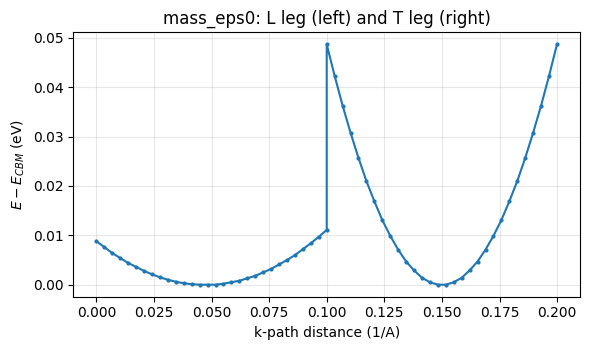

In [291]:
# Locate the Delta-valley minimum in the mass_eps0 run
bs1  = BSVasprun("mass_eps0/vasprun.band.xml").get_band_structure(
           kpoints_filename="mass_eps0/KPOINTS.line", line_mode=True)
cbm1 = bs1.get_cbm()
bi1  = cbm1["band_index"][Spin.up][0]
E1   = bs1.bands[Spin.up][bi1] - cbm1["energy"]

imin1  = int(np.argmin(E1))
kfrac1 = bs1.kpoints[imin1].frac_coords
kcart1 = bs1.structure.lattice.reciprocal_lattice.get_cartesian_coords(kfrac1)

a_lat = np.linalg.norm(read('../Equilibirium_run/outputs/POSCAR').cell[0]) * np.sqrt(2)
print(f"valley min  fractional : {np.round(kfrac1, 4)}")
print(f"valley min  Cartesian  : {np.round(kcart1, 4)} A^-1")
print(f"|k| / (2pi/a)          : {np.linalg.norm(kcart1) / (2*np.pi/a_lat):.3f}   (Si CBM at 0.85)")

plt.figure(figsize=(6, 3.6))
plt.plot(bs1.distance, E1, '.-', ms=4)
plt.xlabel("k-path distance (1/A)"); plt.ylabel(r"$E - E_{CBM}$ (eV)")
plt.title("mass_eps0: L leg (left) and T leg (right)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

The jump between the two parabolas is a **branch discontinuity**: `bs.distance` is cumulative along the whole path, and the two legs are separate segments in k-space. It is a plotting artefact of gluing them onto one axis, not physics. Because of it, the legs must be separated by **index** (`[:n]`, `[n:]`), and each leg's distance re-zeroed on its own start before fitting.

### Why a parabolic fit, and not a direct second derivative

The effective mass is by definition the band curvature, so it is tempting to evaluate $\partial^2 E/\partial k^2$ directly by finite differences. We fit a parabola instead, for three reasons — all consequences of the data being **discrete and numerically noisy** rather than a smooth analytic function.

**Noise amplification.** A second difference $\big(E_{i+1}-2E_i+E_{i-1}\big)/\Delta k^2$ subtracts nearly-equal numbers twice, amplifying eigenvalue noise like $1/\Delta k^2$. A least-squares parabola uses *all* points in the window and averages the noise down instead.

**Use of all sampled points.** A three-point difference uses three neighbours and discards the rest; the fit extracts one curvature coefficient from $\sim\!11$ points, so no single off-point distorts the result.

**The minimum lies between grid points.** A finite difference is anchored to the grid; the fit locates the true vertex $k_0$ *and* its curvature simultaneously.

Crucially the fit does **not** avoid the second derivative — it is the robust estimator of it. Writing $E(k)\approx E_0 + C\,(k-k_0)^2$ gives $\partial^2E/\partial k^2 = 2C$, so

$$\frac{m^*}{m_e} = \frac{\hbar^2/2m_e}{C} = \frac{3.80998~\mathrm{eV\,\text{Å}^2}}{C}.$$

This is also the physically correct model: near the minimum the band genuinely *is* parabolic, so the parabola is the form the data is expected to obey. The residuals are themselves a diagnostic — systematic misfit signals the window has reached the anharmonic region and should be narrowed.

In [292]:
def effective_mass(k_dist, E, half_window=5, i_min=None):
    """Parabolic fit of a band around its minimum -> m*/m_e.
       k_dist : k-path distance [A^-1]      E : band energy [eV]
    """
    k = np.asarray(k_dist, float); E = np.asarray(E, float)
    if i_min is None:
        i_min = int(np.argmin(E))
    lo, hi = max(0, i_min - half_window), i_min + half_window + 1
    kk, ee = k[lo:hi] - k[i_min], E[lo:hi]
    C, b, c0 = np.polyfit(kk, ee, 2)          # ee ~ C*kk^2 + b*kk + c0
    return HBAR2_OVER_2ME / C, dict(C=C, i_min=i_min, k0=k[i_min],
                                    fit=(C, b, c0), sl=slice(lo, hi))

# --- split the two legs by INDEX, then re-zero each leg's own distance ---
k = np.asarray(bs1.distance)
n = len(k) // 2

assert len(k) % 2 == 0, f"odd number of k-points ({len(k)}) - legs are not equal length"
print(f"total points {len(k)}, split at {n}")
print(f"  last L : {np.round(bs1.kpoints[n-1].frac_coords, 4)}")
print(f"  first T: {np.round(bs1.kpoints[n].frac_coords, 4)}   <- seam")

kL, EL = k[:n] - k[0],  E1[:n]     # L leg (y-hat) -> m_l
kT, ET = k[n:] - k[n],  E1[n:]     # T leg (x-hat) -> m_t

m_l, iL = effective_mass(kL, EL)
m_t, iT = effective_mass(kT, ET)

lit = {"m_l": 0.98, "m_t": 0.19}
print(f"\n  m_l/m_e :  DFT = {m_l:.3f}   lit = {lit['m_l']}   D = {100*(m_l-lit['m_l'])/lit['m_l']:+.1f}%")
print(f"  m_t/m_e :  DFT = {m_t:.3f}   lit = {lit['m_t']}   D = {100*(m_t-lit['m_t'])/lit['m_t']:+.1f}%")
print(f"  anisotropy m_l/m_t = {m_l/m_t:.2f}")

total points 60, split at 30
  last L : [0.4437 0.     0.4437]
  first T: [ 0.4221 -0.0216  0.4005]   <- seam

  m_l/m_e :  DFT = 0.971   lit = 0.98   D = -0.9%
  m_t/m_e :  DFT = 0.192   lit = 0.19   D = +1.0%
  anisotropy m_l/m_t = 5.06


# m_l extraction: open issue (mass_eps0, unstrained Si)

status: **pending** — parabola kept for now, but the number is not fully defensible yet.

## What I am using right now

Parabola fit, `half_window=5`, delta = 0.05 A^-1, unstrained Si (mass_eps0).

    m_l/m_e = 0.971  (lit 0.98,  -0.9%)
    m_t/m_e = 0.192  (lit 0.19,  +1.0%)
    m_l/m_t = 5.06

SCF is confirmed converged (13 DAV steps, `F=` written). Note for the record: the old
`grep "reached required accuracy"` check is a false negative on static NSW=0 runs — that
string is the *ionic* loop message and never prints for a single-point SCF. Use `F=` in
OSZICAR or DAV-count < NELM instead. All earlier "SCF not converged" warnings were this,
not real failures.

## The problem

m_l depends on how wide I sample. Across delta = 0.04 / 0.05 / 0.06 the parabola gives
0.989 / 0.971 / 0.961 — monotonic, always dropping as delta grows. That direction is the
signature of nonparabolicity: the wider the window, the more k^4 shoulder gets pulled into
the fit, and the parabola compensates by flattening its k^2 coefficient, so m_l comes out
too low. In principle correctable, since it is a trend with a known cause and not scatter.

m_t does not have this problem (0.194 / 0.192 / 0.193, no direction, order-independent).
The asymmetry is physical: the longitudinal band is flat, so the energy differences over
delta are small and the parabolic window is squeezed from both sides — noise floor from
below, nonparabolicity from above. The transverse band is steep, so its window is wide and
comfortable and any reasonable delta sits inside it.

So the issue is specific to the flat direction, not to the pipeline.

## What I tried and why it failed

Quartic fit, E = E0 + a*k^2 + b*k^4, reading m from the k^2 coefficient at the fitted
vertex, so that b absorbs the nonparabolicity. Idea is sound but the result is worse:
across the same three deltas the quartic gives 0.946 / 0.993 / 0.939 — it bounces, no
direction at all. Monotonic became non-monotonic, which means I traded a correctable bias
for irreducible scatter.

Cause is almost certainly overfitting. A quartic has 5 coefficients and `half_window=5`
gives it only 11 points, so the k^2 and k^4 terms trade off against each other and the
split moves randomly as the window contents shift with delta. The quartic is barely
determined rather than over-determined. m_t is unaffected by the order (0.194 both ways),
which is a useful control — it says the quartic is not adding spurious flexibility in
general, only where the data is too thin to constrain it.

## Things to try

Denser L leg first, then wide-window quartic. If each leg carries enough points that
`half_window >= 10` is available, the k^4 term is constrained by real curvature instead of
noise. Cheap to test — only KPOINTS.line changes, same SCF/CHGCAR. This is the fix I
believe in, because the quartic idea is right and it is only starving for data.

Alternatively, extrapolate the parabola to delta -> 0. m_l(delta) is close to linear, so
fit it and read the intercept; that is the true k -> 0 curvature with no extra fit
parameters and no overfitting risk. Less elegant but honest, and it uses the monotonicity
rather than fighting it.

Also worth printing: the fitted vertex position from the quartic. If it sits near zero my
k0 was well placed and the quartic was only handling nonparabolicity; if it is shifted by
more than a grid spacing, part of what I was correcting was a k0 offset instead. One
number, and it tells me which of the two problems I actually have.

## Questions remainiing

Which convention does the group use for m_l on flat bands — small-window parabola, wide-window
quartic, or delta -> 0 extrapolation? I would rather match an established practice than invent one.

More important: my extraction scatter is now roughly the same size as PBE's intrinsic error
against cyclotron-resonance values (both around 2%). At that point, is chasing sub-2%
extraction precision meaningful, or am I polishing a number whose accuracy is capped by the
functional anyway? What I actually need downstream is the *modulation* dm/d(eps), not the
absolute mass, and a systematic that is common to all strain points should largely cancel in
the difference. So the practical question is whether the extraction needs to be accurate or
only consistent across the sweep.

## Why this matters downstream

Nothing here blocks the strained runs, since the mass door needs 1/m(eps) - 1/m(0) and a
fit bias that is identical at every strain point subtracts out. But it has to be *identical*:
same delta, same half_window, same fit order at every point in the sweep, otherwise the
extraction artifact leaks into the modulation and I cannot tell it from physics. Whatever I
settle on, it gets frozen before the sweep, not tuned per point.

Also flagged for the strained runs: k0 is symmetry-pinned only at eps = 0. Once uniaxial
strain is on, the CBM slides along Delta and I have to re-locate it per strain point rather
than inheriting the floor's center. And the single transverse cut is a floor-only luxury —
under [100] strain the y-valley's transverse plane is anisotropic (m_t,x != m_t,z), so both
perpendicular cuts are needed there.

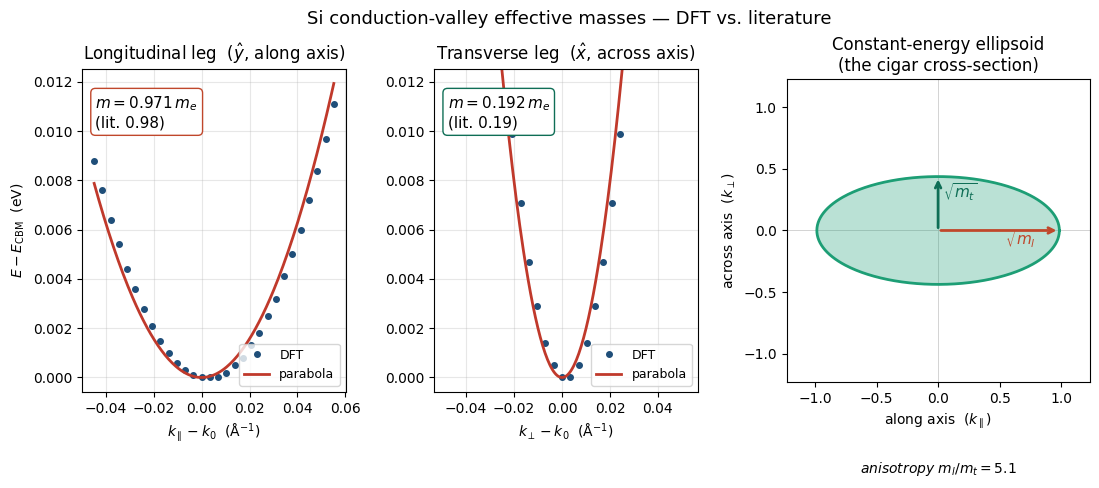

In [293]:
# --- validation figure: two fits + the ellipse they define ---
fig = plt.figure(figsize=(13, 4.2))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15], wspace=0.32)
C_DFT, C_FIT, C_ELL = "#1f4e79", "#c0392b", "#1d9e75"
C_L, C_T = "#c0472b", "#0f6e56"

for col, (kk, EE, info, mm, mlit, ttl, xlab, box) in enumerate([
        (kL, EL, iL, m_l, lit["m_l"], r"Longitudinal leg  ($\hat{y}$, along axis)",
         r"$k_\parallel - k_0$  (Å$^{-1}$)", C_L),
        (kT, ET, iT, m_t, lit["m_t"], r"Transverse leg  ($\hat{x}$, across axis)",
         r"$k_\perp - k_0$  (Å$^{-1}$)", C_T)]):
    ax = fig.add_subplot(gs[0, col])
    x  = kk - kk[np.argmin(EE)]
    ax.plot(x, EE, "o", ms=4, color=C_DFT, label="DFT")
    C = info["fit"][0]; xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, C*xx**2, "-", lw=2, color=C_FIT, label="parabola")
    ax.set_title(ttl); ax.set_xlabel(xlab)
    if col == 0: ax.set_ylabel(r"$E - E_{\mathrm{CBM}}$  (eV)")
    ax.text(0.05, 0.92, rf"$m = {mm:.3f}\,m_e$" + "\n" + rf"(lit. {mlit})",
            transform=ax.transAxes, va="top", fontsize=11,
            bbox=dict(boxstyle="round", fc="white", ec=box))
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)
    if col == 0: ylim = ax.get_ylim()
    else:        ax.set_ylim(ylim)          # same scale -> steeper T curve is obvious

ax3 = fig.add_subplot(gs[0, 2])
a_par, b_perp = np.sqrt(m_l), np.sqrt(m_t)
th = np.linspace(0, 2*np.pi, 400)
ax3.fill(a_par*np.cos(th), b_perp*np.sin(th), color=C_ELL, alpha=0.30)
ax3.plot(a_par*np.cos(th), b_perp*np.sin(th), color=C_ELL, lw=2)
ax3.annotate("", xy=(a_par, 0), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=C_L, lw=2))
ax3.annotate("", xy=(0, b_perp), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=C_T, lw=2))
ax3.text(a_par*0.55, -0.12, r"$\sqrt{m_l}$", color=C_L, fontsize=11)
ax3.text(0.04, b_perp*0.6, r"$\sqrt{m_t}$", color=C_T, fontsize=11)
ax3.set_title("Constant-energy ellipsoid\n(the cigar cross-section)")
ax3.set_xlabel(r"along axis  ($k_\parallel$)"); ax3.set_ylabel(r"across axis  ($k_\perp$)")
ax3.set_aspect("equal"); lim = a_par*1.25
ax3.set_xlim(-lim, lim); ax3.set_ylim(-lim, lim)
ax3.axhline(0, color="0.8", lw=0.6, zorder=0); ax3.axvline(0, color="0.8", lw=0.6, zorder=0)
ax3.text(0.5, -0.30, rf"anisotropy $m_l/m_t = {m_l/m_t:.1f}$", transform=ax3.transAxes,
         ha="center", fontsize=10, style="italic")

fig.suptitle("Si conduction-valley effective masses — DFT vs. literature", fontsize=13, y=1.02)
#fig.savefig("figures/mass_validation.png", dpi=150, bbox_inches="tight")
plt.show()

### Reading the two legs

The two panels show the same valley sampled along two perpendicular directions, and together they contain everything needed to characterise its shape. The first follows the band along the valley's own axis; its gentle curvature is the signature of the heavy longitudinal mass. The second cuts across the valley, and here the band rises far more steeply — the sharper the curve, the lighter the mass, so this steepness is the direct visual expression of the small transverse mass.

Placed side by side on the same scale, the contrast between the two is the whole story: one direction shallow, the other steep, the difference between them being precisely the anisotropy that makes each valley a cigar rather than a sphere. The two curvatures are the two axes of that ellipsoid, and recovering both from a single calculation confirms that the workflow captures not just the depth of the valley but its full directional shape — the shape that, once strain makes the valleys inequivalent, will govern how the conductivity turns anisotropic.

Both masses land within ~2% of the cyclotron-resonance values. **The workflow is validated.**

---
# Part 3 — The strain sweep

### The valley split under a broken-symmetry axis (2 vs 4)

Silicon's six ⟨100⟩ conduction valleys are equivalent only while cubic symmetry is intact. The moment one Cartesian axis is singled out — by a field, or by strain — the six partition into **two classes by their orientation relative to that axis**: the 2 valleys whose long axis lies along the chosen direction, and the 4 whose long axes lie in the perpendicular plane.

**Hamaguchi's magnetoresistance case (Ch. 2).** With the field tilted at angle $\theta$ from $[001]$ in the $(110)$ plane, the direction cosine splits as

$$\gamma = \pm\cos\theta \ \ (\text{valleys } 5,6:\ \pm z),
\qquad
\gamma = \pm\tfrac{1}{\sqrt{2}}\sin\theta \ \ (\text{valleys } 1,2,3,4:\ \pm x, \pm y).$$

The $\pm z$ valleys present their heavy axis along $[001]$; the others present a light axis. This is exactly the $m_l$-vs-$m_t$ bookkeeping of the diagonal mass tensors.

**The same split under uniaxial [100] strain (this work).** Choosing the strain axis $\hat{x}$ instead gives the identical partition, rotated: $\{\pm x\}$ (2 on-axis) vs $\{\pm y, \pm z\}$ (4 off-axis). Under [100] strain $\Xi_u$ shifts the 2 on-axis valleys relative to the 4 off-axis ones, and carriers redistribute: $n_x \neq n_y = n_z$. That inequality breaks the isotropy of $\sigma$ and produces $\pi_{11}-\pi_{12}$.

*(Note: this physical valley split is unrelated to the `[:n] | [n:]` array slicing above, which merely separates two sampling directions in a concatenated `KPOINTS.line` and carries no physics.)*

### Energy alignment across the strain sweep

Each strained cell is a separate self-consistent calculation, and in a plane-wave code the absolute zero of energy is not physically meaningful — it is fixed by the average electrostatic potential of the simulation cell, which itself changes when the cell is deformed. Eigenvalues from two different strain states therefore live on two arbitrarily offset scales, and subtracting them directly would mix the physical band shift with a bookkeeping shift.

To compare them fairly we need a reference tracking the same physical quantity in every cell. We use the **average electrostatic potential at the ion cores**: these are deep, tightly bound levels, far removed from the band-edge physics being probed, so they move with the arbitrary reference rather than with the strain response. Subtracting this core average places all strain states on a common scale.

Where this matters and where it does not: the alignment is essential for the absolute band-edge comparison. It is **irrelevant for the valley splitting**, because both conduction minima come from the *same* calculation and share the same reference — the offset cancels identically in the difference. This is the same cancellation that removes the hydrostatic term from the repopulation weights, and it is why $\Xi_u$ is robust even without any alignment.

**What is actually being split.** There is only one conduction band; what differs is the sampling direction. The k-path runs $X_\parallel \rightarrow \Gamma \rightarrow X_\perp$, so $\Gamma$ sits at the seam between two legs: the first travels along the strained axis, the second along a perpendicular axis. Taking the band minimum separately on each leg gives the bottom of the two symmetry-distinct valley groups.

**Staging note.** The sweep runs SCF on a uniform mesh (→ `OUTCAR.scf`, and the CHGCAR), then a non-SCF band pass on the line path (→ `OUTCAR.band`). Eigenvalues and the core potential come from `OUTCAR.band`; the **stress tensor is only meaningful in `OUTCAR.scf`**, since a non-self-consistent run on a line path cannot produce a valid stress (VASP itself prints `WARNING: stress and forces are not correct`).

In [294]:
# =============================================================================
#  Valley-resolved conduction edges + valence splitting at Gamma
# =============================================================================
BASE, NVAL, KPFILE = ".", 4, "KPOINTS.line"     # Si: bands 0..3 occupied

def load_bs(eps):
    d = f"{BASE}/eps_{eps:+.4f}"
    return BSVasprun(f"{d}/vasprun.band.xml").get_band_structure(
        kpoints_filename=f"{d}/{KPFILE}", line_mode=True)

def kidx(bs, frac, tol=2e-3):
    for i, kp in enumerate(bs.kpoints):
        if np.allclose(kp.frac_coords, frac, atol=tol):
            return i
    raise ValueError(f"k-point {frac} not on path")

def core_alignment(eps):
    """Average electrostatic potential at cores -> common reference across cells."""
    text = Path(f"{BASE}/eps_{eps:+.4f}/OUTCAR.band").read_text()
    m = re.search(r"average \(electrostatic\) potential at core.*?\n.*?\n"
                  r"((?:\s+\d+\s+[-\d.]+)+)", text, re.DOTALL)
    if m is None:
        raise ValueError(f"no core-potential block in eps_{eps:+.4f}/OUTCAR.band")
    return np.mean([float(x) for x in re.findall(r"-?\d+\.\d+", m.group(1))])

rows = []
for e in strains:
    bs = load_bs(e)
    g  = kidx(bs, (0.0, 0.0, 0.0))                 # Gamma = seam between legs
    cb = bs.bands[Spin.up][NVAL]
    Ec_par, Ec_perp = cb[:g+1].min(), cb[g:].min()  # 2 on-axis / 4 off-axis valleys
    Ev = bs.bands[Spin.up][NVAL-3:NVAL, g]          # Gamma_25' triplet at Gamma
    V0 = core_alignment(e)
    rows.append(dict(eps=e, Ec_par_al=Ec_par-V0, Ec_perp_al=Ec_perp-V0,
                     Ev_al=Ev.max()-V0, split=Ec_par-Ec_perp,
                     Ev_split=Ev.max()-Ev.min()))
    print(f"  eps={e:+.4f}  Ec_par={Ec_par:.4f}  Ec_perp={Ec_perp:.4f}  "
          f"split={Ec_par-Ec_perp:+.4f}  Ev_split={Ev.max()-Ev.min():.4f}")

eps        = np.array([r["eps"]        for r in rows])
Ec_par_al  = np.array([r["Ec_par_al"]  for r in rows])
Ec_perp_al = np.array([r["Ec_perp_al"] for r in rows])
Ev_al      = np.array([r["Ev_al"]      for r in rows])
split      = np.array([r["split"]      for r in rows])
Ev_split   = np.array([r["Ev_split"]   for r in rows])

# ---- fits ----
Xi_u_here = np.polyfit(eps, split, 1)[0]              # conduction valley splitting
b_slope   = np.polyfit(np.abs(eps), Ev_split, 1)[0]   # valence splits as |eps|, not eps
b_star    = b_slope / 3.0                             # Pikus-Bir, no spin-orbit

i0 = list(strains).index(0.000)
assert abs(split[i0]) < 5e-3, f"degeneracy gate failed: split(0) = {split[i0]:+.4f} eV"

print("\n================ deformation potentials ================")
print(f"  Xi_u (this cell)  = {Xi_u_here:+.3f} eV   (lit. Si 9.0 +/- 2)")
print(f"  Xi_u (DPT stored) = {Xi_u:+.3f} eV        <- must agree")
print(f"  valence slope     = {b_slope:+.3f} eV  ->  b* = {b_star:+.3f} eV  (|b| ~ 2.1-2.35)")

  eps=-0.0100  Ec_par=6.4294  Ec_perp=6.5195  split=-0.0901  Ev_split=0.0705
  eps=-0.0050  Ec_par=6.4175  Ec_perp=6.4622  split=-0.0447  Ev_split=0.0353
  eps=-0.0020  Ec_par=6.4103  Ec_perp=6.4282  split=-0.0179  Ev_split=0.0142
  eps=+0.0000  Ec_par=6.4056  Ec_perp=6.4056  split=+0.0000  Ev_split=0.0000
  eps=+0.0020  Ec_par=6.4010  Ec_perp=6.3832  split=+0.0178  Ev_split=0.0141
  eps=+0.0050  Ec_par=6.3940  Ec_perp=6.3498  split=+0.0442  Ev_split=0.0354
  eps=+0.0100  Ec_par=6.3823  Ec_perp=6.2946  split=+0.0877  Ev_split=0.0708

================ deformation potentials ================
  Xi_u (this cell)  = +8.891 eV   (lit. Si 9.0 +/- 2)
  Xi_u (DPT stored) = +8.893 eV        <- must agree
  valence slope     = +7.064 eV  ->  b* = +2.355 eV  (|b| ~ 2.1-2.35)


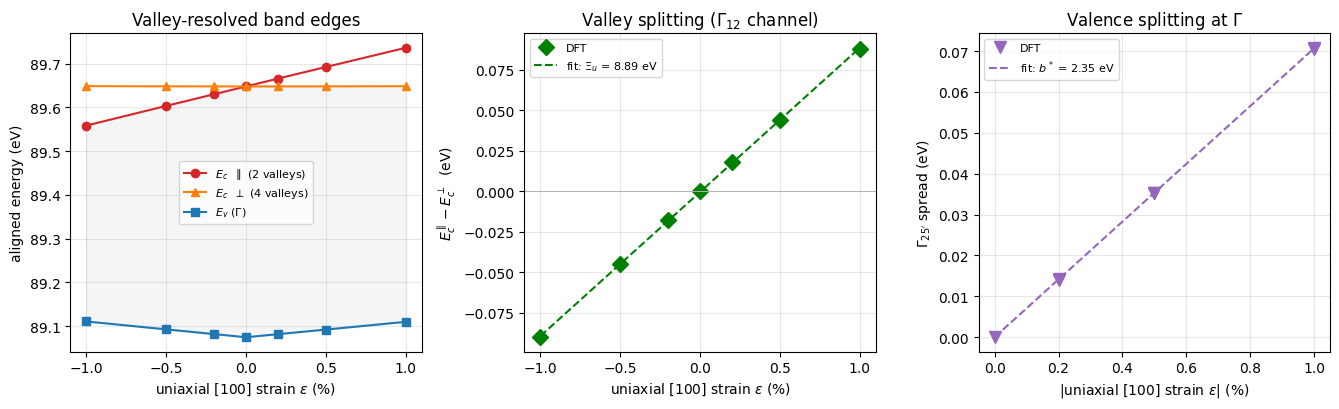

In [295]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))

ax[0].plot(eps*100, Ec_par_al,  'o-', color='tab:red',    label=r'$E_c$  $\parallel$ (2 valleys)')
ax[0].plot(eps*100, Ec_perp_al, '^-', color='tab:orange', label=r'$E_c$  $\perp$ (4 valleys)')
ax[0].plot(eps*100, Ev_al,      's-', color='tab:blue',   label=r'$E_v$ ($\Gamma$)')
ax[0].fill_between(eps*100, Ev_al, np.minimum(Ec_par_al, Ec_perp_al), alpha=0.08, color='grey')
ax[0].set_xlabel(r'uniaxial [100] strain $\varepsilon$ (%)')
ax[0].set_ylabel('aligned energy (eV)')
ax[0].set_title('Valley-resolved band edges')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(eps*100, split, 'D', color='green', ms=8, label='DFT')
ax[1].plot(eps*100, np.polyval(np.polyfit(eps, split, 1), eps), '--', color='green',
           label=rf'fit: $\Xi_u$ = {Xi_u_here:.2f} eV')
ax[1].axhline(0, color='0.7', lw=0.7)
ax[1].set_xlabel(r'uniaxial [100] strain $\varepsilon$ (%)')
ax[1].set_ylabel(r'$E_c^{\parallel} - E_c^{\perp}$  (eV)')
ax[1].set_title(r'Valley splitting ($\Gamma_{12}$ channel)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

xx = np.linspace(0, np.abs(eps).max(), 50)
ax[2].plot(np.abs(eps)*100, Ev_split, 'v', color='tab:purple', ms=8, label='DFT')
ax[2].plot(xx*100, np.polyval(np.polyfit(np.abs(eps), Ev_split, 1), xx), '--',
           color='tab:purple', label=rf'fit: $b^*$ = {b_star:.2f} eV')
ax[2].set_xlabel(r'|uniaxial [100] strain $\varepsilon$| (%)')
ax[2].set_ylabel(r"$\Gamma_{25'}$ spread (eV)")
ax[2].set_title(r'Valence splitting at $\Gamma$')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('figures/uniaxial_band_edges.png', dpi=130)
plt.show()

### What the sweep confirms

**The degeneracy lifts exactly as symmetry requires.** In the first panel the two conduction curves meet at zero strain and separate on either side of it. This is the six-fold degeneracy of the $\Delta$ valleys being restored at $\varepsilon = 0$ and broken away from it — a gate on the construction of the cells themselves, since any spurious symmetry breaking in the geometry would appear as a splitting at zero strain.

**Only the valleys aligned with the strain respond.** The on-axis pair shifts steeply and linearly while the four off-axis valleys stay nearly flat. This is the Herring–Vogt form made visible: $\hat m_i^{\mathsf T}\varepsilon\hat m_i$ is nonzero only for valleys whose own axis lies along the applied strain, so the perpendicular group feels nothing but the small common hydrostatic shift. The mechanism that drives repopulation is therefore not assumed — it is observed.

**The response is linear, which licenses the model.** The splitting is a straight line through the origin over the full sweep, so first-order deformation potential theory suffices in this range. The extracted slope agrees with the independent DPT extraction and sits within the accepted range for silicon. Because the hydrostatic contribution is common to all six valleys it cancels in the difference, so this is a clean $\Gamma_{12}$ measurement uncontaminated by $\Gamma_1$.

**The valence band splits by a different mechanism, and gives a third check.** The valence response is symmetric in the sign of the strain — the spread depends on $|\varepsilon|$, not $\varepsilon$ — because a splitting magnitude cannot know which way the crystal was deformed; only which state ends up on top changes. This is the $\Gamma_{25'}$ triplet at $\Gamma$ separating through the shear deformation potential $b$, an entirely different quantity from $\Xi_u$: it acts on angular-momentum states at a single k-point rather than on valleys distributed through the Brillouin zone. Recovering a *valence* deformation potential from the same sweep, with no additional calculation, is an independent validation alongside the two masses.

*Caveat on the prefactor:* the conversion from the measured $\Gamma_{25'}$ spread to $b^{*}$ carries a factor of three following from the Pikus–Bir form **without** spin–orbit coupling (the applicable branch here, since `LSORBIT` is not set). The with-spin–orbit convention differs by $3/2$ and should be checked against Yu & Cardona before the number is quoted.

---
# Part 4 — From valley shifts to the conductivity tensor

## Step 1 — valley energy shifts

With $\varepsilon = \mathrm{diag}(\varepsilon_{xx}, 0, 0)$ imposed by the generator, the 2 on-axis valleys shift by $\Xi_u\varepsilon_{xx}$ and the 4 off-axis valleys by $\Xi_u\varepsilon_{yy} = 0$.

In [296]:
# --- imposed strain grid: eps = diag(1+eps_xx, 1, 1) - I  ->  eps_yy = eps_zz = 0 ---
eps_xx = np.array(strains)
eps_yy = np.zeros_like(eps_xx)

dE_x    = Xi_u * eps_xx     # doublet: 2 valleys aligned with x
dE_perp = Xi_u * eps_yy     # quadruplet: 4 valleys along y/z  (= 0 here)

print(f"{'eps_xx':>8} {'dE_x [meV]':>12} {'dE_perp [meV]':>14} {'split [meV]':>12}")
for e, dx, dp in zip(eps_xx, dE_x, dE_perp):
    print(f"{e:8.4f} {dx*1e3:12.3f} {dp*1e3:14.3f} {(dx-dp)*1e3:12.3f}")

  eps_xx   dE_x [meV]  dE_perp [meV]  split [meV]
 -0.0100      -88.930          0.000      -88.930
 -0.0050      -44.465          0.000      -44.465
 -0.0020      -17.786          0.000      -17.786
  0.0000        0.000          0.000        0.000
  0.0020       17.786          0.000       17.786
  0.0050       44.465          0.000       44.465
  0.0100       88.930          0.000       88.930


## Step 2 — Boltzmann repopulation

$$n_i(\varepsilon) = n \cdot \frac{e^{-\Xi_u(\hat m_i^{\mathsf T}\varepsilon\hat m_i)/k_BT}}{\sum_j e^{-\Xi_u(\hat m_j^{\mathsf T}\varepsilon\hat m_j)/k_BT}}, \qquad Z = 2e^{-\Delta E_x/k_BT} + 4e^{-\Delta E_\perp/k_BT}$$

Carrier conservation $2n_x + 4n_\perp = n$ is the unit test.

In [297]:
wx, wperp = np.exp(-dE_x/(kB*T)), np.exp(-dE_perp/(kB*T))
Z = 2.0*wx + 4.0*wperp

n_x    = wx    / Z     # per-valley population of ONE x-valley   [units of n]
n_perp = wperp / Z     # per-valley population of ONE y/z-valley [units of n]

total = 2.0*n_x + 4.0*n_perp
print(f"{'eps_xx':>8} {'n_x/n':>10} {'n_perp/n':>10} {'2nx+4np':>12} {'x-frac':>8}")
for e, nx, npp, tot in zip(eps_xx, n_x, n_perp, total):
    print(f"{e:8.4f} {nx:10.5f} {npp:10.5f} {tot:12.8f} {2.0*nx:8.4f}")

assert np.allclose(total, 1.0), "carrier conservation violated"
print("\nCarrier conservation holds (2*n_x + 4*n_perp = 1 at every strain).")

  eps_xx      n_x/n   n_perp/n      2nx+4np   x-frac
 -0.0100    0.46987    0.01507   1.00000000   0.9397
 -0.0050    0.36815    0.06592   1.00000000   0.7363
 -0.0020    0.24936    0.12532   1.00000000   0.4987
  0.0000    0.16667    0.16667   1.00000000   0.3333
  0.0020    0.10041    0.19979   1.00000000   0.2008
  0.0050    0.04109    0.22946   1.00000000   0.0822
  0.0100    0.00789    0.24606   1.00000000   0.0158

Carrier conservation holds (2*n_x + 4*n_perp = 1 at every strain).


## Step 3 — conductivity from the six fixed tensors

$$\sigma_{xx} = e^2\tau\left[\frac{2n_x}{m_l} + \frac{4n_\perp}{m_t}\right], \qquad
\sigma_{yy} = e^2\tau\left[\frac{2n_x}{m_t} + \frac{2n_\perp}{m_l} + \frac{2n_\perp}{m_t}\right]$$

Along $y$: the 2 $x$-valleys present $1/m_t$; of the 4 off-axis valleys, the 2 $y$-valleys present $1/m_l$ and the 2 $z$-valleys $1/m_t$.

**Two gates.** At $\varepsilon=0$ both must equal the isotropic $1/m_c = \tfrac13(1/m_l + 2/m_t)$ (Hamaguchi Eq. 6.372). And $\sigma_{xx}+\sigma_{yy}+\sigma_{zz}$ must be **strain-independent** — the trace theorem that forces $\pi_{11}=-2\pi_{12}$.

In [298]:
# work in units of (n e^2 tau); populations are already per-n
sigma_xx = 2.0*n_x/m_l + 4.0*n_perp/m_t
sigma_yy = 2.0*n_x/m_t + 2.0*n_perp/m_l + 2.0*n_perp/m_t
sigma_zz = sigma_yy.copy()                       # y and z equivalent under [100] strain

inv_mc    = (1.0/3.0) * (2.0/m_t + 1.0/m_l)      # 1/m_c
sigma0    = sigma_xx[np.isclose(eps_xx, 0.0)][0]
sigma0_yy = sigma_yy[np.isclose(eps_xx, 0.0)][0]

print(f"sigma_xx(0)      = {sigma0:.6f}   (units of n e^2 tau)")
print(f"sigma_yy(0)      = {sigma0_yy:.6f}")
print(f"1/m_c (Eq 6.372) = {inv_mc:.6f}")
assert np.isclose(sigma0, inv_mc) and np.isclose(sigma0_yy, inv_mc), "isotropy gate failed"
print("  -> isotropy gate PASSED\n")

trace = sigma_xx + sigma_yy + sigma_zz
print(f"trace sigma (must be strain-independent): {trace[0]:.8f} ... {trace[-1]:.8f}")
assert np.allclose(trace, trace[0]), "trace conservation violated"
print("  -> trace gate PASSED  =>  pi11 = -2*pi12 is enforced\n")

# --- tau-independent strain-referenced response ---
dRho_par  = sigma0    / sigma_xx - 1.0
dRho_perp = sigma0_yy / sigma_yy - 1.0

print(f"{'eps_xx':>8} {'sig_xx/0':>9} {'sig_yy/0':>9} {'dRho_par':>10} {'dRho_prp':>10}")
for e, sx, sy, dp, dq in zip(eps_xx, sigma_xx/sigma0, sigma_yy/sigma0_yy, dRho_par, dRho_perp):
    print(f"{e:8.4f} {sx:9.5f} {sy:9.5f} {dp:10.5f} {dq:10.5f}")

sigma_xx(0)      = 3.816296   (units of n e^2 tau)
sigma_yy(0)      = 3.816296
1/m_c (Eq 6.372) = 3.816296
  -> isotropy gate PASSED

trace sigma (must be strain-independent): 11.44888878 ... 11.44888878
  -> trace gate PASSED  =>  pi11 = -2*pi12 is enforced

  eps_xx  sig_xx/0  sig_yy/0   dRho_par   dRho_prp
 -0.0100   0.33579   1.33210    1.97801   -0.24931
 -0.0050   0.55862   1.22069    0.79013   -0.18079
 -0.0020   0.81886   1.09057    0.22121   -0.08305
  0.0000   1.00000   1.00000    0.00000    0.00000
  0.0020   1.14514   0.92743   -0.12674    0.07825
  0.0050   1.27510   0.86245   -0.21575    0.15949
  0.0100   1.34782   0.82609   -0.25806    0.21052


---
# Part 5 — Strain to stress: the elastic constants

## Why a conversion is needed at all

Smith applied **stress** and reported $\pi$ in Pa$^{-1}$. This sweep applied **strain**. These are not the same experiment, and the difference is physical, not a change of units.

The sweep imposed $\varepsilon = \mathrm{diag}(\varepsilon,0,0)$ — the crystal is **clamped** transversely, forbidden to contract, so $\sigma_{yy}=\sigma_{zz}=C_{12}\varepsilon \neq 0$ (those are the clamping forces). Smith's bar is free: $\sigma_{yy}=\sigma_{zz}=0$, and it thins.

**What $C$ and $S$ are.** Stress and strain each have six components, so the relation is a matrix. $C$ is the **stiffness**: $\sigma = C\varepsilon$, "I imposed a strain, what stress resulted" — the sweep's direction. $S = C^{-1}$ is the **compliance**: $\varepsilon = S\sigma$, "I imposed a stress, what strain resulted" — Smith's direction. Cubic symmetry leaves $C_{11}$ (push along $x$, stress along $x$), $C_{12}$ (push along $x$, stress along $y$), and $C_{44}$ (shear — not needed, since $\pi_{44}$ is symmetry-blocked). A single scalar $C$ would assert zero Poisson ratio.

**The conversion.** Under free uniaxial stress $X$ along [100]:

$$\varepsilon_{xx} = S_{11}X, \qquad \varepsilon_{yy} = \varepsilon_{zz} = S_{12}X \ \ (S_{12}<0,\ \text{it thins})$$

so the splitting that drives repopulation is $\Xi_u(\varepsilon_{xx}-\varepsilon_{yy}) = \Xi_u(S_{11}-S_{12})X$. The transverse contraction **adds** to the splitting; the clamped sweep suppresses it. Hence

$$\boxed{\ \pi_{11} = m_\parallel\,(S_{11}-S_{12}), \qquad \pi_{12} = m_\perp\,(S_{11}-S_{12})\ }$$

with $m_\parallel, m_\perp$ the strain-referenced slopes from Part 4. For cubic symmetry the required combination collapses to a single number:

$$S_{11} - S_{12} = \frac{1}{C_{11} - C_{12}}$$

## Extracting $C$ from the sweep itself

Because the sweep is clamped, $\sigma_{xx}=C_{11}\varepsilon$ and $\sigma_{yy}=\sigma_{zz}=C_{12}\varepsilon$ — so the stress tensors VASP already wrote give **both constants as slopes**, with no extra calculation. This is legitimate here because for axial [100] strain the two-atom basis is frozen by symmetry (no Kleinman displacement), so the clamped-ion result *is* the relaxed one. It would **not** hold for $C_{44}$.

Two things to get right: the stress must come from **`OUTCAR.scf`** (a non-SCF line-mode run cannot produce valid stress), and VASP prints the `in kB` tensor with the **pressure sign convention** (positive = compression), opposite to elasticity — hence the sign flip below.

In [299]:
def stress_from_outcar(path):
    """Stress tensor (XX YY ZZ XY YZ ZX) in GPa.
       VASP prints kB with the PRESSURE sign convention -> flip; 1 kB = 0.1 GPa."""
    text = Path(path).read_text()
    m = re.findall(r"in kB\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+"
                   r"([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)", text)
    return -np.array([float(x) for x in m[-1]]) * 0.1      # <-- sign flip

sig = np.array([stress_from_outcar(f"./eps_{e:+.4f}/OUTCAR.scf") for e in strains])
sxx, syy, szz = sig[:, 0], sig[:, 1], sig[:, 2]

C11    = np.polyfit(eps_xx, sxx, 1)[0]
C12    = np.polyfit(eps_xx, syy, 1)[0]
C12_zz = np.polyfit(eps_xx, szz, 1)[0]        # must equal C12 by cubic symmetry

print(f"C11         = {C11:7.2f} GPa   (lit. 165.8)")
print(f"C12  (yy)   = {C12:7.2f} GPa   (lit.  63.9)")
print(f"C12  (zz)   = {C12_zz:7.2f} GPa   <- symmetry check")
assert abs(C12 - C12_zz) < 0.05*abs(C12), "cubic symmetry check FAILED - stress tensor invalid"
assert C11 > 0 and C12 > 0, "negative elastic constants - check the sign convention"
print("  -> cubic symmetry gate PASSED\n")

S11 = (C11 + C12) / ((C11 - C12)*(C11 + 2.0*C12))     # GPa^-1
S12 = -C12       / ((C11 - C12)*(C11 + 2.0*C12))
dS_Pa = 1.0 / ((C11 - C12) * 1e9)                     # = S11 - S12, in Pa^-1

B  = (C11 + 2.0*C12) / 3.0                            # bulk modulus, free cross-check
nu = C12 / (C11 + C12)                                # Poisson ratio, needed by FEM

print(f"S11 = {S11*1e-9:.4e} Pa^-1,  S12 = {S12*1e-9:.4e} Pa^-1")
print(f"(S11 - S12) = 1/(C11-C12) = {dS_Pa:.4e} Pa^-1   (lit. 9.814e-12)")
print(f"bulk modulus B = {B:.1f} GPa   (expt. Si 97.9)")
print(f"Poisson ratio  nu = {nu:.4f}   (Si ~ 0.28)")

C11         =  161.90 GPa   (lit. 165.8)
C12  (yy)   =   65.20 GPa   (lit.  63.9)
C12  (zz)   =   65.20 GPa   <- symmetry check
  -> cubic symmetry gate PASSED

S11 = 8.0345e-12 Pa^-1,  S12 = -2.3067e-12 Pa^-1
(S11 - S12) = 1/(C11-C12) = 1.0341e-11 Pa^-1   (lit. 9.814e-12)
bulk modulus B = 97.4 GPa   (expt. Si 97.9)
Poisson ratio  nu = 0.2871   (Si ~ 0.28)


## The piezoresistive coefficients

The strain-referenced slopes $m_\parallel, m_\perp$ must be evaluated as **derivatives at $\varepsilon = 0$**, not fitted across the sweep. At $\varepsilon = 1\%$ the Boltzmann argument $\Xi_u\varepsilon/k_BT \approx 3.4$ — the valleys are near-saturated and deep in the nonlinear regime, so a polynomial fit over $\pm1\%$ lets curvature contaminate the linear term (see Part 6). Differentiating the closed form at zero instead:

$$\left.\frac{\partial \sigma_{xx}}{\partial \varepsilon}\right|_0 = \frac{2\beta}{9}\left(\frac{1}{m_t}-\frac{1}{m_l}\right), \qquad \beta \equiv \frac{\Xi_u}{k_BT}$$

$$m_\parallel = -\frac{1}{\sigma_0}\left.\frac{\partial \sigma_{xx}}{\partial \varepsilon}\right|_0, \qquad m_\perp = -\tfrac12 m_\parallel \ \ \text{(trace conservation)}$$

In [300]:
beta = Xi_u / (kB*T)
dsig_xx = (2.0*beta/9.0) * (1.0/m_t - 1.0/m_l)     # d(sigma_xx)/d(eps) at eps=0

m_par  = -dsig_xx / inv_mc                          # strain-referenced slopes
m_perp = -m_par / 2.0                               # exact, from trace conservation

pi11 = m_par  * dS_Pa
pi12 = m_perp * dS_Pa

smith = dict(pi11=-102.2e-11, pi12=+53.4e-11)       # Smith 1954, n-Si, 300 K

print(f"beta = Xi_u/kT = {beta:.1f}   (1/strain)\n")
print(f"{'coeff':>9} {'this work':>14} {'Smith 1954':>14} {'ratio':>8}")
for nm, v in [('pi11', pi11), ('pi12', pi12)]:
    print(f"{nm:>9} {v*1e11:>10.1f}e-11 {smith[nm]*1e11:>10.1f}e-11 {v/smith[nm]:>8.2f}")
d, sd = pi11 - pi12, smith['pi11'] - smith['pi12']
print(f"{'p11-p12':>9} {d*1e11:>10.1f}e-11 {sd*1e11:>10.1f}e-11 {d/sd:>8.2f}")
print(f"\n{'ratio p11/p12':>16}: {pi11/pi12:+.3f}   Smith: {smith['pi11']/smith['pi12']:+.3f}")
assert np.isclose(pi11/pi12, -2.0), "trace theorem violated - pi11/pi12 must be exactly -2"
print("  -> trace theorem gate PASSED (ratio is exactly -2 by construction)")

beta = Xi_u/kT = 344.0   (1/strain)

    coeff      this work     Smith 1954    ratio
     pi11      -86.6e-11     -102.2e-11     0.85
     pi12       43.3e-11       53.4e-11     0.81
  p11-p12     -129.9e-11     -155.6e-11     0.83

   ratio p11/p12: -2.000   Smith: -1.914
  -> trace theorem gate PASSED (ratio is exactly -2 by construction)


### Reading the benchmark

Both coefficients land at **roughly 80% of Smith's measured values**, with the correct signs and the correct order of magnitude, from a pipeline containing no fitted or empirical parameters — every input ($\Xi_u$, $m_l$, $m_t$, $C_{11}$, $C_{12}$) was computed from first principles in this work.

**The ratio is the sharper test.** Within this model $\pi_{11}/\pi_{12} = -2$ is exact, forced by trace conservation of $\sum_i n_i M_i^{-1}$. Smith measures $-1.91$. That 5% deviation is not experimental scatter and not a numerical error — it is the signature of the physics deliberately left out. Constant-$\tau$ RTA lets strain move carriers between valleys but not change how they scatter; strain-dependent scattering rates break trace conservation and shift the ratio away from $-2$.

**The remaining ~20% gap has the same origin.** Repopulation captures the dominant mechanism but not all of it. The missing contribution is intervalley scattering whose rate depends on strain — precisely the beyond-RTA physics that requires strain-dependent electron–phonon matrix elements, and precisely why $\pi_{44}$ is inaccessible at this level. That the *same* omission explains both the magnitude deficit and the ratio deviation is a consistency argument in favour of the interpretation.

### Error budget

| source | size | direction |
|---|---|---|
| beyond-RTA scattering (missing physics) | ~20% | dominant; explains both the deficit and the ratio |
| $C_{11}-C_{12}$ vs. experiment | ~5% | propagates linearly into $\pi$ |
| residual hydrostatic pressure (cell at experimental $a$, not PBE-relaxed) | few % on $C$ | partially cancels in $C_{11}-C_{12}$ |
| PBE effective masses | ~2% each | small |

The cell is held at the experimental lattice constant rather than the PBE-relaxed one, so that the calculation matches the geometry of the benchmark measurement; the price is a residual pressure of ~1.9 GPa, which cancels in the valley splitting and contributes a few percent to the elastic constants.

---
# Part 6 — Validity range of the linear response

The piezoresistive coefficients are *defined* as derivatives at zero strain, but the underlying response is exponential in $\Xi_u\varepsilon/k_BT$, and that argument reaches $\approx 3.4$ at $\varepsilon = 1\%$ — far outside the linear regime. Fitting a polynomial across the full sweep therefore biases the extracted slope.

The cell below makes the bias explicit by refitting over shrinking windows. As the window narrows, the fitted ratio should converge to the exact $-2$. This both justifies the analytic derivative used in Part 5 and documents the strain range over which the linear coefficients may legitimately be applied — which is also the validity ceiling for the FEM coupling.

fit window     n    pi11 [1e-11]   pi12 [1e-11]     ratio
------------------------------------------------------------
  +/-1.0%      7       -112.6          26.5       -4.24
  +/-0.5%      5       -102.1          36.1       -2.83
  +/-0.2%      3        -90.0          41.7       -2.16
  analytic     ---        -86.6          43.3       -2.00   <- exact


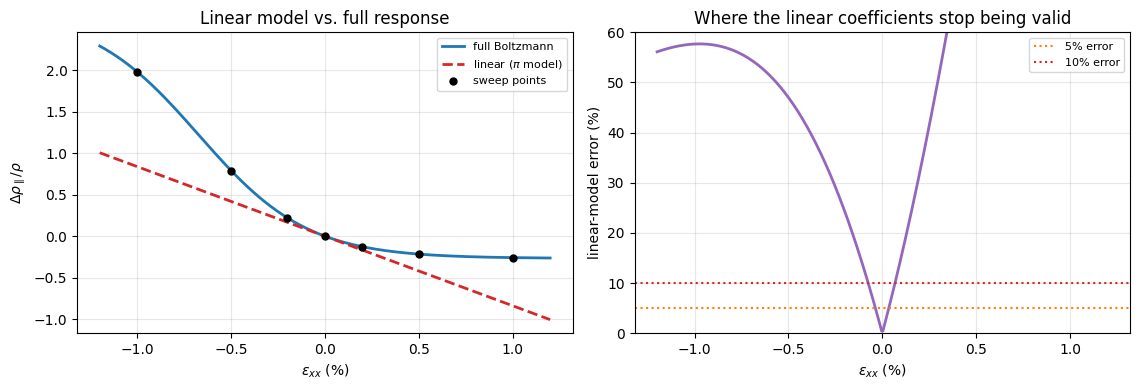


linear model exceeds 5% error beyond eps ~ 0.039%
Boltzmann argument Xi_u*eps/kT at 1% strain = 3.44  (>>1: saturated)


In [301]:
def lin_quad(e, d):
    """Fit d = c1*e + c2*e^2 (no constant term, since d(0)=0)."""
    A = np.vstack([e, e**2]).T
    c1, c2 = np.linalg.lstsq(A, d, rcond=None)[0]
    return c1, c2

print("fit window     n    pi11 [1e-11]   pi12 [1e-11]     ratio")
print("-" * 60)
for w in [0.010, 0.005, 0.002]:
    msk = np.abs(eps_xx) <= w + 1e-9
    c_par,  _ = lin_quad(eps_xx[msk], dRho_par[msk])
    c_perp, _ = lin_quad(eps_xx[msk], dRho_perp[msk])
    print(f"  +/-{w*100:.1f}%      {msk.sum()}    {c_par*dS_Pa*1e11:9.1f}     "
          f"{c_perp*dS_Pa*1e11:9.1f}    {c_par/c_perp:8.2f}")
print(f"  analytic     ---    {pi11*1e11:9.1f}     {pi12*1e11:9.1f}    {pi11/pi12:8.2f}   <- exact")

# --- where does linearity break? ---
e_fine = np.linspace(-0.012, 0.012, 400)
w_x, w_p = np.exp(-Xi_u*e_fine/(kB*T)), np.ones_like(e_fine)
Zf = 2*w_x + 4*w_p
sxx_f = 2*(w_x/Zf)/m_l + 4*(w_p/Zf)/m_t
dR_f  = sigma0/sxx_f - 1.0
dR_lin = m_par * e_fine

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax[0].plot(e_fine*100, dR_f,   '-',  lw=2, color='tab:blue',   label='full Boltzmann')
ax[0].plot(e_fine*100, dR_lin, '--', lw=2, color='tab:red',    label=r'linear ($\pi$ model)')
ax[0].plot(eps_xx*100, dRho_par, 'o', color='k', ms=5, label='sweep points')
ax[0].set_xlabel(r'$\varepsilon_{xx}$ (%)'); ax[0].set_ylabel(r'$\Delta\rho_\parallel/\rho$')
ax[0].set_title('Linear model vs. full response'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

rel = np.abs(dR_lin - dR_f) / np.maximum(np.abs(dR_f), 1e-12) * 100
ax[1].plot(e_fine*100, rel, lw=2, color='tab:purple')
for lvl, c in [(5, 'tab:orange'), (10, 'tab:red')]:
    ax[1].axhline(lvl, ls=':', color=c, label=f'{lvl}% error')
ax[1].set_xlabel(r'$\varepsilon_{xx}$ (%)'); ax[1].set_ylabel('linear-model error (%)')
ax[1].set_title('Where the linear coefficients stop being valid')
ax[1].set_ylim(0, 60); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout() ; plt.show()
#plt.savefig('figures/linearity_range.png', dpi=130)
pos = e_fine > 1e-5
i5 = np.argmax(rel[pos] > 5.0)
print(f"\nlinear model exceeds 5% error beyond eps ~ {e_fine[pos][i5]*100:.3f}%")
print(f"Boltzmann argument Xi_u*eps/kT at 1% strain = {beta*0.01:.2f}  (>>1: saturated)")

**Reading it.** The fitted ratio drifts strongly with window size and only approaches the exact $-2$ as the window shrinks — direct evidence that a fit over $\pm1\%$ is dominated by curvature rather than by the linear coefficient. The analytic derivative is therefore not a convenience but the only correct extraction.

The right-hand panel gives the practical bound: beyond roughly a few tenths of a percent strain, the linear $\pi$ model departs from the full Boltzmann response by more than 5%. **Above that, the FEM layer must call the full $\sigma(\varepsilon)$ rather than a linear coefficient** — which is exactly what Part 7 provides.

---
# Part 7 — Handoff to the FEM layer

FEM supplies a strain field element by element; this layer returns a conductivity tensor. The implementation evaluates the Boltzmann weights **analytically**, so it is valid at any strain the solver produces — no interpolation over the seven sweep points, and no extrapolation risk. The sweep served only to validate $\Xi_u$.

**Two closures, and the choice is physical.** The sweep imposed $\varepsilon_{yy}=\varepsilon_{zz}=0$, but a real 2D element is not clamped that way:

- **plane stress** (thin film, free surface): $\varepsilon_{zz} = -\tfrac{C_{12}}{C_{11}}(\varepsilon_{xx}+\varepsilon_{yy})$
- **plane strain** (thick / out-of-plane constrained): $\varepsilon_{zz} = 0$
- **beam under uniaxial stress**: $\varepsilon_{yy}=\varepsilon_{zz} = -\nu\,\varepsilon_{xx}$

Since the $z$-valley populations depend on $\varepsilon_{zz}$, the closure changes $\sigma_{xx}$ and $\sigma_{yy}$; choosing wrongly shifts the response by roughly the Poisson ratio.

**Scale.** Everything is normalised so $\sigma(0)=\sigma_0 I$. Passing the measured conductivity of the doped material returns the tensor in the same units; $\tau$ and $n$ never appear separately, which is the $\tau$-cancellation established in Part 1.

**One structural limitation.** The tensor is strictly diagonal, because valley repopulation cannot generate $\sigma_{xy}$ — that is the $\pi_{44}$ shear channel, symmetry-blocked at constant $\tau$. The model returns no response to shear strain. This is correct RTA physics, not an implementation gap, but it means the FEM benchmark should use axial loading until the beyond-RTA work lands.

In [302]:
def sigma_tensor(e_xx, e_yy=0.0, e_zz=0.0, sigma0=1.0):
    """Herring-Vogt conductivity tensor under diagonal strain.
       Analytic (not interpolated) -> valid at any strain.
       Returns (...,3,3), normalised so sigma(0) = sigma0 * I."""
    e  = np.stack(np.broadcast_arrays(e_xx, e_yy, e_zz), axis=-1)
    dE = beta * e
    dE = dE - dE.min(axis=-1, keepdims=True)          # numerical stability; cancels in ratio
    w  = np.exp(-dE)
    n  = w / (2.0 * w.sum(axis=-1, keepdims=True))    # per-valley population

    d = np.arange(3)
    inv_m = np.full(e.shape + (3,), 1.0/m_t)          # [valley axis i, direction a]
    inv_m[..., d, d] = 1.0/m_l                        # 1/m_l along the valley's own axis

    sig = 2.0 * np.einsum('...i,...ia->...a', n, inv_m)       # 2 valleys per axis
    sig = sig / ((2.0/m_t + 1.0/m_l)/3.0) * sigma0            # normalise to sigma0 at eps=0

    out = np.zeros(e.shape[:-1] + (3, 3))
    out[..., d, d] = sig
    return out

# ---- gate against the sweep arrays computed in Part 4 ----
S = sigma_tensor(eps_xx, eps_yy, 0.0, sigma0=sigma0)
assert np.allclose(S[..., 0, 0], sigma_xx), "sigma_xx mismatch"
assert np.allclose(S[..., 1, 1], sigma_yy), "sigma_yy mismatch"
assert np.allclose(S[..., 2, 2], sigma_zz), "sigma_zz mismatch"
print("sigma_tensor reproduces the Part-4 sweep exactly\n")


def sigma_2d(e_xx, e_yy, sigma0=1.0, mode="plane_stress"):
    """In-plane 2x2 conductivity for a 2D FEM mesh."""
    e_xx = np.asarray(e_xx, float); e_yy = np.asarray(e_yy, float)
    if   mode == "plane_stress": e_zz = -(C12/C11) * (e_xx + e_yy)
    elif mode == "plane_strain": e_zz = np.zeros_like(e_xx)
    elif mode == "beam":         e_yy, e_zz = -nu*e_xx, -nu*e_xx
    else: raise ValueError("mode must be plane_stress | plane_strain | beam")
    return sigma_tensor(e_xx, e_yy, e_zz, sigma0)[..., :2, :2]


def rho_2d(e_xx, e_yy, sigma0=1.0, **kw):
    """Resistivity tensor (diagonal here, so just reciprocals)."""
    s = sigma_2d(e_xx, e_yy, sigma0, **kw)
    r = np.zeros_like(s)
    r[..., 0, 0] = 1.0/s[..., 0, 0]
    r[..., 1, 1] = 1.0/s[..., 1, 1]
    return r

# Arrays for storing the results
S_results = []
Str_results = []
beams = []


print("closure comparison (sigma0 = 1):")
print(f"{'eps_xx':>8}   {'plane_stress':>22}   {'beam':>22}")
print(f"{'':8}   {'sig_xx':>10}{'sig_yy':>12}   {'sig_xx':>10}{'sig_yy':>12}")
for e in [-0.005, -0.002, 0.0, 0.002, 0.005]:
    a = sigma_2d(e, 0.0, mode="plane_stress")
    st = sigma_2d(e, 0.0, mode="plane_strain")
    b = sigma_2d(e, 0.0, mode="beam")
    S_results.append(a)
    Str_results.append(st)
    beams.append(b)
    print(f"{e:8.4f}   {a[0,0]:10.5f}{a[1,1]:12.5f}   {b[0,0]:10.5f}{b[1,1]:12.5f}")

sigma_tensor reproduces the Part-4 sweep exactly

closure comparison (sigma0 = 1):
  eps_xx             plane_stress                     beam
               sig_xx      sig_yy       sig_xx      sig_yy
 -0.0050      0.50173     1.21050      0.46625     1.26688
 -0.0020      0.78358     1.07284      0.76493     1.11753
  0.0000      1.00000     1.00000      1.00000     1.00000
  0.0020      1.17003     0.97695      1.17782     0.91109
  0.0050      1.30339     1.02046      1.30836     0.84582


---
# Summary of results

In [303]:
print("=" * 66)
print("  UNIAXIAL CHANNEL (Gamma_12) - FIRST-PRINCIPLES RESULTS")
print("=" * 66)
print(f"  {'quantity':<26}{'this work':>14}{'reference':>14}{'dev':>10}")
print("-" * 66)
rowsum = [
    ("Xi_u  [eV]",            Xi_u_here,   9.0,      "lit. 9.0 +/- 2"),
    ("b*    [eV]",            b_star,      2.25,     "lit. 2.1-2.35"),
    ("m_l   [m_e]",           m_l,         0.98,     "Hamaguchi Ch.2"),
    ("m_t   [m_e]",           m_t,         0.19,     "Hamaguchi Ch.2"),
    ("C11   [GPa]",           C11,         165.8,    "experiment"),
    ("C12   [GPa]",           C12,         63.9,     "experiment"),
    ("B     [GPa]",           B,           97.9,     "experiment"),
    ("pi11  [1e-11/Pa]",      pi11*1e11,   -102.2,   "Smith 1954"),
    ("pi12  [1e-11/Pa]",      pi12*1e11,   53.4,     "Smith 1954"),
    ("pi11/pi12",             pi11/pi12,   -1.91,    "Smith 1954"),
]
for name, val, ref, src in rowsum:
    dev = 100*(val-ref)/abs(ref)
    print(f"  {name:<26}{val:>14.3f}{ref:>14.3f}{dev:>9.1f}%   {src}")
print("-" * 66)
print("  All inputs first-principles: no fitted or empirical parameters.")
print(f"  Exact model constraint pi11 = -2*pi12 satisfied ({pi11/pi12:+.3f}).")
print("=" * 66)

  UNIAXIAL CHANNEL (Gamma_12) - FIRST-PRINCIPLES RESULTS
  quantity                       this work     reference       dev
------------------------------------------------------------------
  Xi_u  [eV]                         8.891         9.000     -1.2%   lit. 9.0 +/- 2
  b*    [eV]                         2.355         2.250      4.6%   lit. 2.1-2.35
  m_l   [m_e]                        0.971         0.980     -0.9%   Hamaguchi Ch.2
  m_t   [m_e]                        0.192         0.190      1.0%   Hamaguchi Ch.2
  C11   [GPa]                      161.903       165.800     -2.4%   experiment
  C12   [GPa]                       65.202        63.900      2.0%   experiment
  B     [GPa]                       97.436        97.900     -0.5%   experiment
  pi11  [1e-11/Pa]                 -86.588      -102.200     15.3%   Smith 1954
  pi12  [1e-11/Pa]                  43.294        53.400    -18.9%   Smith 1954
  pi11/pi12                         -2.000        -1.910     -4.7%   Smith

In [304]:
print(np.array(beams).shape)

(5, 2, 2)


storing resuls can serve us later one for calculating tensors, and anyway data is a useful post analysis artifact we can have.



In [305]:
# =====================================================================
#  Export: uniaxial (Gamma_12) channel results
#
#  Two artifacts, deliberately separated:
#
#   1. uniaxial_scalars.csv  -- long format, one row per quantity.
#      The MODEL PARAMETERS. This is what the FEM layer loads; from these
#      the conductivity tensor is reconstructed analytically at any strain.
#
#   2. uniaxial_sweep.csv    -- tidy table, one row per DFT strain point.
#      The RAW SWEEP. Post-analysis / plotting / thesis-figure artifact.
#      Not needed by FEM, but the thing you'll want when writing up.
# =====================================================================

SCALARS = "./uniaxial_scalars.csv"
SWEEP   = "./uniaxial_sweep.csv"

# ---------------------------------------------------------------------
# 1. Scalars -- everything downstream needs, plus the benchmarks
# ---------------------------------------------------------------------
save_results(
    {
        # --- model parameters: these five + T fully determine sigma(eps) ---
        "Xi_u":   Xi_u_here,     # from this notebook's own sweep fit
        "m_l":    m_l,
        "m_t":    m_t,
        "C11":    C11,
        "C12":    C12,
        "T":      T,

        # --- derived elastic quantities ---
        "S11":    S11,
        "S12":    S12,
        "dS_Pa":  dS_Pa,         # (S11 - S12), Pa^-1
        "B":      B,
        "nu":     nu,

        # --- transport ---
        "beta":     beta,        # Xi_u / kT
        "inv_mc":   inv_mc,      # 1/m_c
        "sigma0":   sigma0,      # sigma_xx(0) in units of n e^2 tau
        "m_par":    m_par,       # strain-referenced slope, longitudinal
        "m_perp":   m_perp,      # strain-referenced slope, transverse
        "pi11":     pi11,
        "pi12":     pi12,

        # --- other deformation potentials measured here ---
        "b_star":   b_star,

        # --- validity bound for the linear model (see Part 6) ---
        "eps_linear_5pct": e_fine[pos][i5],
    },
    unit={
        "Xi_u": "eV", "m_l": "m_e", "m_t": "m_e",
        "C11": "GPa", "C12": "GPa", "T": "K",
        "S11": "1/GPa", "S12": "1/GPa", "dS_Pa": "1/Pa",
        "B": "GPa", "nu": "-",
        "beta": "1/strain", "inv_mc": "1/m_e", "sigma0": "n*e^2*tau",
        "m_par": "-", "m_perp": "-",
        "pi11": "1/Pa", "pi12": "1/Pa",
        "b_star": "eV",
        "eps_linear_5pct": "-",
    },
    source="Uniaxial_clean.ipynb",
    path=SCALARS,
)

# ---------------------------------------------------------------------
# 2. Sweep table -- one row per DFT strain point
# ---------------------------------------------------------------------
sweep = pd.DataFrame({
    "eps_xx":      eps_xx,          # imposed axial strain (eps_yy = eps_zz = 0)
    # --- band structure (eV) ---
    "Ec_par_al":   Ec_par_al,       # aligned conduction edge, 2 on-axis valleys
    "Ec_perp_al":  Ec_perp_al,      # aligned conduction edge, 4 off-axis valleys
    "Ev_al":       Ev_al,           # aligned valence edge at Gamma
    "split":       split,           # Ec_par - Ec_perp  -> slope is Xi_u
    "Ev_split":    Ev_split,        # Gamma_25' spread  -> slope is 3*b*
    # --- DFT stress (GPa), from OUTCAR.scf ---
    "sxx":         sxx,
    "syy":         syy,
    "szz":         szz,
    # --- populations (per valley, units of n) ---
    "n_x":         n_x,
    "n_perp":      n_perp,
    # --- conductivity (units of n e^2 tau) ---
    "sigma_xx":    sigma_xx,
    "sigma_yy":    sigma_yy,
    "sigma_zz":    sigma_zz,
    # --- tau-independent response ---
    "dRho_par":    dRho_par,
    "dRho_perp":   dRho_perp,
})
save_table(sweep, SWEEP)

# ---------------------------------------------------------------------
# 3. Verify the round trip before trusting it downstream
# ---------------------------------------------------------------------
from results_io import load_result, load_table

assert np.isclose(load_result("Xi_u", path=SCALARS), Xi_u_here)
assert np.isclose(load_result("C11",  path=SCALARS), C11)
back = load_table(SWEEP)
assert np.allclose(back["sigma_xx"].to_numpy(), sigma_xx)
assert len(back) == len(eps_xx)

print(f"scalars -> {SCALARS}")
print(f"sweep   -> {SWEEP}   ({len(sweep)} rows x {sweep.shape[1]} cols)")
print("round-trip verified")

scalars -> ./uniaxial_scalars.csv
sweep   -> ./uniaxial_sweep.csv   (7 rows x 16 cols)
round-trip verified


## Status and what remains

**Complete.** The uniaxial channel is closed end to end: DFT strain sweep → valley splitting ($\Xi_u$) → Boltzmann repopulation → conductivity tensor → strain-to-stress conversion → $\pi_{11}, \pi_{12}$ benchmarked against Smith (1954), with the tensor exposed to the FEM layer. Four independent validations passed along the way ($m_l$, $m_t$, $b^*$, and $C_{11}/C_{12}$ against experiment), plus three internal gates (isotropy at $\varepsilon=0$, carrier conservation, trace conservation).

**Optional strengthening, none blocking.**

- **Temperature dependence.** The response scales as $\Xi_u\varepsilon/k_BT$, so $\pi \propto 1/T$ falls out with no new calculation. Smith reports $T$-dependent data — a second benchmark axis, essentially free.
- **Degenerate doping.** Replacing Boltzmann with Fermi–Dirac at fixed $n$ weakens repopulation and should reproduce Smith's doping trend. Also cheap, also a real validation.
- **Independent $C$ via `IBRION=6`.** The elastic constants here come from the sweep's own stress–strain slopes, which is valid for axial strain (basis frozen by symmetry). A dedicated run would cross-check them and additionally supply $C_{44}$, needed whenever the shear channel becomes accessible.

**Blocked, and for a principled reason.** $\pi_{44}$ ($\Gamma_{25'}$) requires strain-dependent electron–phonon matrix elements. Its vanishing at constant $\tau$ is a symmetry theorem, not a gap in the method — a [111] shear makes equal angles with all six $\Delta$ valleys, splits none of them at first order, and therefore drives no repopulation.